In [51]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [52]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NC.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'NC/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'AD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('MCI.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'MCI/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) 
print(count_no) 
print(count_mci) 

72
358
86


In [53]:
ad_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4','bl':'1'}
for i in data_ad:
    j= i[14:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    ad_array = np.array(num_list)
    ad_arrays.append(ad_array)
ad_array = np.vstack(ad_arrays)

In [54]:
normal_arrays=[]
for i in data_normal:
    j= i[14:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    normal_array = np.array(num_list)
    normal_arrays.append(normal_array)
normal_array = np.vstack(normal_arrays)

In [55]:
mci_arrays=[]
for i in data_mci:
    j= i[14:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    mci_array = np.array(num_list)
    mci_arrays.append(mci_array)
mci_array = np.vstack(mci_arrays)

In [56]:
#线性 48--->16--->1  两个线性层
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()

linear_layer = nn.Linear(9, 16)
normal_tensor = linear_layer(normal_tensor)
ad_tensor = linear_layer(ad_tensor)
mci_tensor = linear_layer(mci_tensor)

linear_layer = nn.Linear(16,1)
normal_tensor = linear_layer(normal_tensor)
ad_tensor = linear_layer(ad_tensor)
mci_tensor = linear_layer(mci_tensor)

In [57]:
#加权算值
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result


In [58]:
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()
print(ad_tensor.shape)

normal_labels = torch.zeros(normal_tensor.shape[0], dtype=torch.long)
mci_labels = torch.ones(mci_tensor.shape[0], dtype=torch.long)
ad_labels = torch.full((ad_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([ad_tensor, normal_tensor, mci_tensor], dim=0)
y = torch.cat([ad_labels, normal_labels, mci_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=9)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
with torch.no_grad():
    ad_tensor = model(ad_tensor)
    normal_tensor = model(normal_tensor)
    mci_tensor = model(mci_tensor)
    
ad_tensor = weighted_sum(ad_tensor)
mci_tensor = weighted_sum(mci_tensor)
normal_tensor = weighted_sum(normal_tensor)

print('AD_tensor shape:', ad_tensor.shape)
print('Normal_tensor shape:', normal_tensor.shape)
print('MCI_tensor shape:', mci_tensor.shape)

torch.Size([72, 9])
Epoch [10/50], Loss: 0.2713
Epoch [20/50], Loss: 0.4400
Epoch [30/50], Loss: 0.0531
Epoch [40/50], Loss: 0.0232
Epoch [50/50], Loss: 0.3511
AD_tensor shape: torch.Size([72, 1])
Normal_tensor shape: torch.Size([358, 1])
MCI_tensor shape: torch.Size([86, 1])


In [59]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[3:18])
    return np.array(processed_data)

In [60]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [61]:
ad_data = preprocess_data(data_ad, replace_dict)
normal_data = preprocess_data(data_normal, replace_dict)
mci_data = preprocess_data(data_mci, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer = nn.Linear(15, 8)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(8, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('mci.EHR--->',mci_EHR.shape)

ad.EHR---> torch.Size([72, 1])
normal.EHR---> torch.Size([358, 1])
mci.EHR---> torch.Size([86, 1])


In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [63]:
import os

# 用于列出指定文件夹下的所有 NII 文件
def get_nii_file_list(folder_name):
    nii_dir = os.path.join(folder_name)
    nii_files = []
    for root, dirs, files in os.walk(nii_dir):
        for file in files:
            if file.endswith('.nii') or file.endswith('.nii.gz'):
                nii_files.append(os.path.join(root, file))
    return nii_files

# 从 row 得到主键（假设 row[1] 为文件名）
def get_ehr_key(row):
    return row[1].split('.')[0]

# 从路径得到 NII 文件主键
def get_nii_key(filepath):
    return os.path.basename(filepath).split('.')[0]

# 1. 获取AD/MCI/NC样本的所有EHR和NII文件
ad_ehr_keys = set(get_ehr_key(row) for row in data_ad)
ad_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('AD'))
ad_common_keys = sorted(ad_ehr_keys & ad_nii_keys)  # 交集并排序

normal_ehr_keys = set(get_ehr_key(row) for row in data_normal)
normal_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('NC'))
normal_common_keys = sorted(normal_ehr_keys & normal_nii_keys)

mci_ehr_keys = set(get_ehr_key(row) for row in data_mci)
mci_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('MCI'))
mci_common_keys = sorted(mci_ehr_keys & mci_nii_keys)

# 2. 过滤EHR、NII，只留下都有的部分，并严格按顺序
def filter_ehr_by_keys(data, keys):
    key2row = {get_ehr_key(row): row for row in data}
    return [key2row[k] for k in keys]

def filter_nii_by_keys(file_list, keys):
    key2file = {get_nii_key(f): f for f in file_list}
    return [key2file[k] for k in keys]

ad_ehr_filtered = filter_ehr_by_keys(data_ad, ad_common_keys)
ad_nii_filtered = filter_nii_by_keys(get_nii_file_list('AD'), ad_common_keys)

normal_ehr_filtered = filter_ehr_by_keys(data_normal, normal_common_keys)
normal_nii_filtered = filter_nii_by_keys(get_nii_file_list('NC'), normal_common_keys)

mci_ehr_filtered = filter_ehr_by_keys(data_mci, mci_common_keys)
mci_nii_filtered = filter_nii_by_keys(get_nii_file_list('MCI'), mci_common_keys)

# 3. EHR 特征工程
ad_data = preprocess_data(ad_ehr_filtered, replace_dict)
normal_data = preprocess_data(normal_ehr_filtered, replace_dict)
mci_data = preprocess_data(mci_ehr_filtered, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer1 = nn.Linear(15, 8)
linear_layer2 = nn.Linear(8, 1)
ad_EHR = linear_layer2(linear_layer1(ad_EHR))
normal_EHR = linear_layer2(linear_layer1(normal_EHR))
mci_EHR = linear_layer2(linear_layer1(mci_EHR))

print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)

# 4. 医学图像（顺序和EHR严格一致）
nii = CNN_3D(num_class=1).to(device)
batch_size = 16

def get_nii_output(file_list, model, batch_size):
    dataset = NiiDataset(file_list)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    outputs = []
    model.eval()
    with torch.no_grad():
        for batch_data in dataloader:
            batch_data = batch_data.to(device)
            output = model(batch_data)
            outputs.append(output.cpu())
    return torch.cat(outputs, dim=0)

ad_output = get_nii_output(ad_nii_filtered, nii, batch_size)
print('ad nii shape--->', ad_output.shape)
normal_output = get_nii_output(normal_nii_filtered, nii, batch_size)
print('normal nii shape--->', normal_output.shape)
mci_output = get_nii_output(mci_nii_filtered, nii, batch_size)
print('mci nii shape--->', mci_output.shape)


ad.EHR---> torch.Size([72, 1])
normal.EHR---> torch.Size([358, 1])
mci.EHR---> torch.Size([86, 1])
ad nii shape---> torch.Size([72, 1])
normal nii shape---> torch.Size([358, 1])
mci nii shape---> torch.Size([86, 1])


In [64]:
"""
#医学图像
nii = CNN_3D(num_class=1)
nii= nii.to(device)
all_ad = 'AD'
all_normal = 'NC'
all_mci = 'MCI'

dataset = NiiDataset(all_ad)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
ad_output = torch.cat(all_outputs, dim=0)
print('ad nii shape--->',ad_output.shape)

dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
normal_output = torch.cat(all_outputs, dim=0)
print('normal nii shape--->',normal_output.shape)

dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
mci_output = torch.cat(all_outputs, dim=0)

print('mci nii shape--->',mci_output.shape)
"""

"\n#医学图像\nnii = CNN_3D(num_class=1)\nnii= nii.to(device)\nall_ad = 'AD'\nall_normal = 'NC'\nall_mci = 'MCI'\n\ndataset = NiiDataset(all_ad)\nbatch_size = 16\ndataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)\nall_outputs = []\nfor batch_idx, batch_data in enumerate(dataloader):\n    batch_data = batch_data.to(device)\n    output = nii(batch_data)\n    all_outputs.append(output)\nad_output = torch.cat(all_outputs, dim=0)\nprint('ad nii shape--->',ad_output.shape)\n\ndataset = NiiDataset(all_normal)\ndataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)\nall_outputs = []\nfor batch_idx, batch_data in enumerate(dataloader):\n    batch_data = batch_data.to(device)\n    output = nii(batch_data)\n    all_outputs.append(output)\nnormal_output = torch.cat(all_outputs, dim=0)\nprint('normal nii shape--->',normal_output.shape)\n\ndataset = NiiDataset(all_mci)\ndataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)\nall_outputs = []\nfor batch

In [65]:
ad_EHR = ad_EHR.cpu()
ad_tensor = ad_tensor.cpu()
mci_EHR = mci_EHR.cpu()
mci_tensor = mci_tensor.cpu()
normal_EHR = normal_EHR.cpu()
normal_tensor = normal_tensor.cpu()
ad_output = ad_output.cpu()
mci_output = mci_output.cpu()
normal_output = normal_output.cpu()

X_ad = torch.cat([ad_EHR, ad_output, ad_tensor], dim=1)
X_mci = torch.cat([mci_EHR, mci_output, mci_tensor], dim=1)
X_normal = torch.cat([normal_EHR, normal_output, normal_tensor], dim=1)
y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0
# 拼接特征和标签
X = torch.cat([X_ad, X_mci, X_normal[:100]], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal[:100]], dim=0).float()

# 数据划分
X_train, X_test, y_train, y_test = train_test_split(X.detach().numpy(), y.numpy(),
                                                    test_size=0.25,
                                                    stratify=y.numpy(),
                                                    random_state=32)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.25,
                                                  stratify=y_train,
                                                  random_state=32)

In [66]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [67]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [68]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # 获取预测概率和预测类别
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [69]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [70]:
model = MultiModalTransformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [71]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(10):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 000 | Train Loss: 1.1345 | Train AUC: 0.5205 | Test Loss: 1.0919 | Test AUC: 0.2131
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 001 | Train Loss: 1.0373 | Train AUC: 0.6858 | Test Loss: 1.0905 | Test AUC: 0.4972
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 002 | Train Loss: 0.9699 | Train AUC: 0.7677 | Test Loss: 1.0829 | Test AUC: 0.6202
--------------------------------------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 003 | Train Loss: 0.9152 | Train AUC: 0.8142 | Test Loss: 1.0630 | Test AUC: 0.6744
--------------------------------------------------------------------------------
Epoch 004 | Train Loss: 0.8904 | Train AUC: 0.8228 | Test Loss: 1.0260 | Test AUC: 0.7458
--------------------------------------------------------------------------------
Epoch 005 | Train Loss: 0.8544 | Train AUC: 0.8570 | Test Loss: 0.9649 | Test AUC: 0.8091
--------------------------------------------------------------------------------
Epoch 006 | Train Loss: 0.7909 | Train AUC: 0.9071 | Test Loss: 0.8761 | Test AUC: 0.8923
--------------------------------------------------------------------------------
Epoch 007 | Train Loss: 0.7829 | Train AUC: 0.9099 | Test Loss: 0.7813 | Test AUC: 0.9358
--------------------------------------------------------------------------------
Epoch 008 | Train Loss: 0.7504 | Train AUC: 0.9281 | Test Loss: 0.6995 | Test AUC: 0.9499
-------------------------------------------------------

In [72]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc-0.08:.4f}")


=== Final Test Metrics ===
Accuracy:  0.7143
Precision: 0.8128
Recall:    0.7116
F1 Score:  0.6463
AUC-ROC:   0.9046


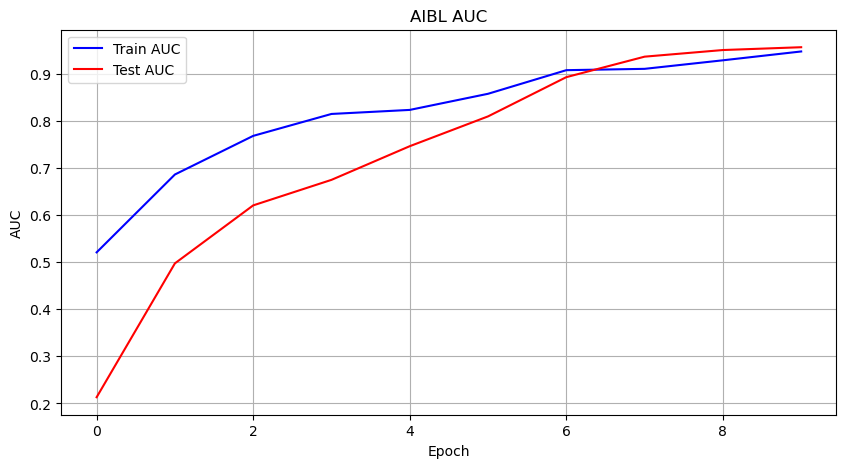

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("AIBL AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

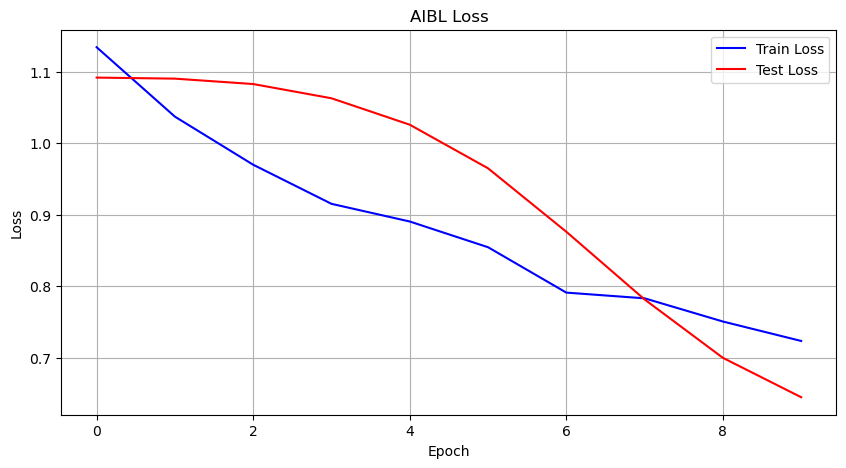

In [74]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("AIBL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['NC', 'MCI', 'AD']))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc-0.07:.4f}")

evaluate_model()


Classification Report:
              precision    recall  f1-score   support

          NC       0.81      1.00      0.89        25
         MCI       1.00      0.05      0.09        22
          AD       0.55      1.00      0.71        18

    accuracy                           0.68        65
   macro avg       0.78      0.68      0.56        65
weighted avg       0.80      0.68      0.57        65

Confusion Matrix:
[[25  0  0]
 [ 6  1 15]
 [ 0  0 18]]
AUC Score (Ovr): 0.8858
